P.K.M.P. KUMARA
230353N 

1. Implement the intensity transformation

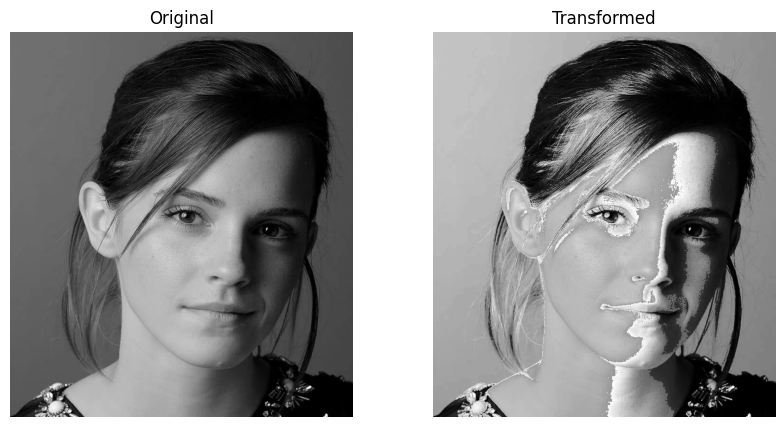

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def intensity_transform(im, breakpoints):   #Define Intensity Transform Func.
    im = np.asarray(im, dtype=np.float64)
    output = np.zeros_like(im)
    filled = np.zeros_like(im, dtype=bool)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        if x1 == x0:
            continue  # vertical jump, skip

        mask = (im >= x0) & (im <= x1) & (~filled)
        output[mask] = y0 + (y1 - y0) * (im[mask] - x0) / (x1 - x0)
        filled |= mask

    return np.clip(output, 0, 255).astype(np.uint8)

img = Image.open('emma_01.jpg').convert('L')  #image in grayscale
img_arr = np.array(img)

breakpoints = [                    #Breakpoints
    [0,   0],
    [50,  50],
    [50,  100],
    [150, 255],
    [150, 150],
    [255, 255],
]

transformed = intensity_transform(img_arr, breakpoints) # Apply transform
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  #show original and transformed pics
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

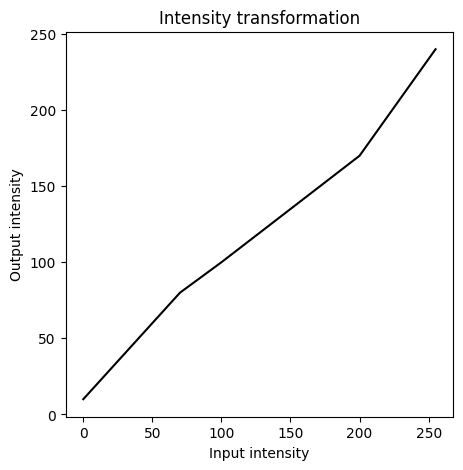

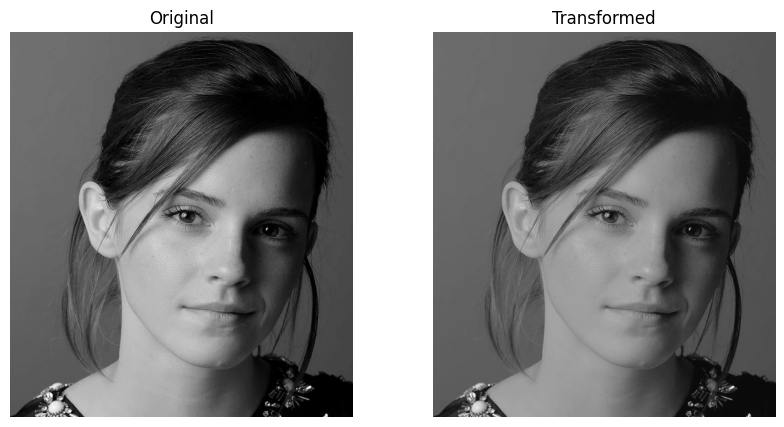

In [44]:
breakpoints = [      #my break points
    [0,   10],
    [70, 80],
    [100, 100],
    [200, 170],          #left side of the face more bright. I reduced it.
    [255, 240],
]

transformed = intensity_transform(img_arr, breakpoints)

bp = np.array(breakpoints)         #plot transformation graph
plt.figure(figsize=(5, 5))
plt.plot(bp[:, 0], bp[:, 1], color='black')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity transformation')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()